<a href="https://colab.research.google.com/github/AsmaaYassinDev/Context-Aware-Fraud-Detection/blob/main/train_logistic_baseline_V2_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload 'kaggle.json':


Saving kaggle.json to kaggle.json
Loading and Optimizing Data...


/tmp/ipykernel_6943/54991343.py:82: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max: df[col] = df[col].astype(np.float16)
/tmp/ipykernel_6943/54991343.py:82: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max: df[col] = df[col].astype(np.float16)
/tmp/ipykernel_6943/54991343.py:82: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max: df[col] = df[col].astype(np.float16)
/tmp/ipykernel_6943/54991343.py:82: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max: df[col] = df[col].astype(np.float16)
/tmp/ipykernel_6943/54991343.py:82: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max: df[col] = df[col].astype(np.float16)
/tmp/ipykernel_6943/54991343.p

Filtering columns...

--- ROBUST UID GENERATION START ---


/tmp/ipykernel_6943/54991343.py:136: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour'] = (df['TransactionDT'] // 3600) % 24
/tmp/ipykernel_6943/54991343.py:147: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['UID'] = s_card + '_' + s_addr + '_' + s_email


Generating Behavioral Features (Strictly Prior Expanding Windows)...


/tmp/ipykernel_6943/54991343.py:159: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['User_Trans_Count'] = df.groupby('UID').cumcount()
/tmp/ipykernel_6943/54991343.py:162: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['User_Mean_Amt'] = df.groupby('UID')['TransactionAmt'].transform(lambda x: x.shift().expanding().mean())
/tmp/ipykernel_6943/54991343.py:165: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

✅ Features Created (Leakage-Free).

--- TRAINING LOGISTIC REGRESSION BASELINE ---
Preparing Data (Imputing & Scaling)...
Fitting Logistic Regression (Class Weight='balanced')...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



--- EVALUATION RESULTS ---
Decision Threshold: 0.50 (Standard)
ROC-AUC:        0.8247
Precision:      0.1121
Recall:         0.7116
F1-Score:       0.1936

Generating Confusion Matrix...


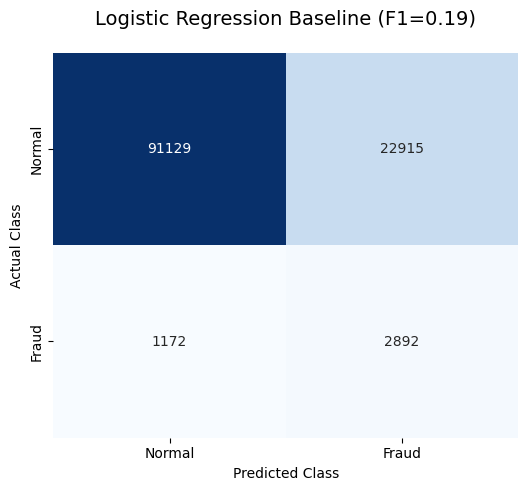

In [1]:
# Imports necessary operating system interfaces for file handling
import os
# Imports garbage collection module to manage memory manually
import gc
# Imports NumPy for high-performance numerical array operations
import numpy as np
# Imports Pandas for data manipulation and DataFrame structures
import pandas as pd
# Imports Google Colab utilities for file uploading
from google.colab import files
# Imports preprocessing tools: LabelEncoder for categories, StandardScaler for normalization
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Imports SimpleImputer to fill missing values (Required for Logistic Regression)
from sklearn.impute import SimpleImputer
# Imports metrics for evaluating model performance
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
# Imports the Logistic Regression algorithm (Linear model for classification)
from sklearn.linear_model import LogisticRegression
# Imports Matplotlib for generating static plots
import matplotlib.pyplot as plt
# Imports Seaborn for creating aesthetically pleasing statistical graphics
import seaborn as sns

# =========================================================
# 1. ROBUST DATA LOADING
# =========================================================

# Defines a function to handle dataset acquisition automatically
def force_download():
    # Checks if the main dataset file already exists in the current directory
    if os.path.exists('train_transaction.csv'):
        # Notifies that data is present; skips download to save time
        print("✅ Data found.")
        return

    # Checks for the existence of the Kaggle API token in the required directory
    if not os.path.exists('/root/.kaggle/kaggle.json'):
        # Prompts for the upload of the 'kaggle.json' API token file
        print("Please upload 'kaggle.json':")
        # Triggers the file upload widget
        files.upload()
        # Creates the hidden .kaggle directory if it does not exist
        os.system('mkdir -p ~/.kaggle')
        # Moves the uploaded JSON file to the standard Kaggle configuration path
        os.system('cp kaggle.json ~/.kaggle/')
        # Sets file permissions to Read/Write for the owner only (security requirement)
        os.system('chmod 600 ~/.kaggle/kaggle.json')

    # Downloads the specific competition dataset using the Kaggle CLI
    os.system('kaggle competitions download -c ieee-fraud-detection')
    # Unzips the main archive, overwriting existing files if necessary
    os.system('unzip -o ieee-fraud-detection.zip')
    # Unzips the transaction CSV file
    os.system('unzip -o train_transaction.csv.zip')
    # Unzips the identity CSV file
    os.system('unzip -o train_identity.csv.zip')

# Executes the download check and setup function
force_download()

# Defines a function to reduce DataFrame memory footprint by optimizing data types
def reduce_mem_usage(df):
    # Iterates through each column in the DataFrame
    for col in df.columns:
        # Retrieves the data type of the current column
        col_type = df[col].dtype
        # Skips optimization for object (string) columns
        if col_type != object:
            # Calculates the minimum and maximum values in the column
            c_min, c_max = df[col].min(), df[col].max()
            # Checks if the column is an integer type
            if str(col_type)[:3] == 'int':
                # Downcasts to int8 if values fit within range
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max: df[col] = df[col].astype(np.int8)
                # Downcasts to int16 if values fit within range
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max: df[col] = df[col].astype(np.int16)
                # Downcasts to int32 if values fit within range
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max: df[col] = df[col].astype(np.int32)
            # Handles float types
            else:
                # Downcasts to float16 if values fit within range
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max: df[col] = df[col].astype(np.float16)
                # Downcasts to float32 if values fit within range
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max: df[col] = df[col].astype(np.float32)
    # Returns the optimized DataFrame
    return df

print("Loading and Optimizing Data...")
# Loads transaction data and applies memory reduction immediately
train_trans = reduce_mem_usage(pd.read_csv('train_transaction.csv'))
# Loads identity data and applies memory reduction immediately
train_id = reduce_mem_usage(pd.read_csv('train_identity.csv'))
# Merges the two DataFrames on 'TransactionID' using a left join (keeping all transactions)
df = pd.merge(train_trans, train_id, on='TransactionID', how='left')
# Deletes the original separate DataFrames to free up RAM
del train_trans, train_id
# Forces garbage collection to reclaim memory
gc.collect()

# =========================================================
# 2. FEATURE ENGINEERING (LEAKAGE-FREE)
# =========================================================

# 1. Sort by Time
# Sorts dataset by TransactionDT to ensure chronological order (Past -> Future)
df = df.sort_values('TransactionDT').reset_index(drop=True)

# A. Filtering
print("Filtering columns...")
# Drops columns where more than 95% of values are null (Sparse data removal)
df = df.drop(columns=df.columns[df.isnull().mean() > 0.95])
# Drops columns that have only 1 unique value (Zero variance removal)
df = df.drop(columns=df.nunique()[df.nunique() == 1].index)

# B. Imputation
# Fills missing categorical values with 'Unknown'
for col in df.select_dtypes(include=['object']).columns: df[col] = df[col].fillna('Unknown')
# Fills missing numerical values with -1
for col in df.select_dtypes(exclude=['object']).columns: df[col] = df[col].fillna(-1)

# C. Timezone Fix
# Converts 'id_14' to string if it exists (treating it as a category)
if 'id_14' in df.columns: df['id_14'] = df['id_14'].astype(str)

# D. Encoding
# Iterates through categorical columns to convert text to numbers
for col in df.select_dtypes(include=['object']).columns:
    # Skips the columns used for UID generation to keep them raw for now
    if col not in ['card1', 'addr1', 'P_emaildomain']:
        # Encodes category strings into integers
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# E. User Profiling & Entity Resolution
print("\n--- ROBUST UID GENERATION START ---")
# Calculates the hour of day
df['hour'] = (df['TransactionDT'] // 3600) % 24

# Construct UID Robustly
# Converts Card ID to string, handling nulls/errors
s_card = df['card1'].astype(str).replace({'-1': 'NoCard', 'nan': 'NoCard'})
# Converts Address to string, handling nulls/errors
s_addr = df['addr1'].astype(str).replace({'-1': 'NoAddr', 'nan': 'NoAddr', '0': 'NoAddr'})
# Converts Email to string, handling nulls/errors
s_email = df['P_emaildomain'].astype(str).replace({'Unknown': 'NoEmail', 'nan': 'NoEmail'})

# Creates the composite UID string
df['UID'] = s_card + '_' + s_addr + '_' + s_email
# Encodes the unique UID strings into integers
df['UID'] = LabelEncoder().fit_transform(df['UID'])

# Encode remaining objects (The components of the UID)
for col in ['card1', 'addr1', 'P_emaildomain']:
    if df[col].dtype == 'object':
         df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# F. Behavioral Profiling (Strictly Prior Expanding Windows)
print("Generating Behavioral Features (Strictly Prior Expanding Windows)...")
# Velocity: Running count of PRIOR transactions for this UID (Starts at 0)
df['User_Trans_Count'] = df.groupby('UID').cumcount()

# Spending Deviation: Expanding Mean of strictly prior transaction amounts for this UID
df['User_Mean_Amt'] = df.groupby('UID')['TransactionAmt'].transform(lambda x: x.shift().expanding().mean())
df['User_Mean_Amt'] = df['User_Mean_Amt'].fillna(df['TransactionAmt']) # Neutralize the first transaction
# Normalizes current transaction amount against the user's history
df['Amt_Deviation'] = df['TransactionAmt'] / (df['User_Mean_Amt'] + 1e-5)

# Time Behavior: Expanding Mean per Hour of strictly prior transactions for this UID
df['User_Hour_Mean'] = df.groupby(['UID', 'hour'])['TransactionAmt'].transform(lambda x: x.shift().expanding().mean())
df['User_Hour_Mean'] = df['User_Hour_Mean'].fillna(df['TransactionAmt']) # Neutralize the first transaction
# Normalizes current transaction amount against the user's hourly history
df['Time_Behavior_Deviation'] = df['TransactionAmt'] / (df['User_Hour_Mean'] + 1e-5)

print("✅ Features Created (Leakage-Free).")


# =========================================================
# 3. SPLITTING (STRICT 80/20 TIME-SERIES)
# =========================================================

# Calculates split index at 80% mark
split_idx = int(len(df) * 0.8)
# Creates Training Data (Past)
train_df = df.iloc[:split_idx]
# Creates Test Data (Future)
test_df = df.iloc[split_idx:]

# Defines columns to exclude from training
exclude = ['isFraud', 'TransactionID', 'TransactionDT', 'UID', 'User_Mean_Amt', 'User_Hour_Mean']
# Selects feature columns
features = [c for c in df.columns if c not in exclude]

# Separates Features (X) and Target (y)
X_train, y_train = train_df[features], train_df['isFraud']
X_test, y_test = test_df[features], test_df['isFraud']

# =========================================================
# 4. LOGISTIC REGRESSION TRAINING
# =========================================================
print("\n--- TRAINING LOGISTIC REGRESSION BASELINE ---")
print("Preparing Data (Imputing & Scaling)...")

# Logistic Regression requires scaling and handling NaN/Infinity better than XGBoost.
# Imputation: Replaces missing values with the median of the column.
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
# Uses the training imputer statistics to transform the test set (avoids leakage)
X_test_imp = imputer.transform(X_test)

# Scaling: Standardizes features (mean=0, variance=1).
# Crucial for Linear Models because coefficients depend on the scale of input variables.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc = scaler.transform(X_test_imp)

print("Fitting Logistic Regression (Class Weight='balanced')...")
# Initializes Logistic Regression
# class_weight='balanced': Penalizes mistakes on the minority class (Fraud) more heavily.
# solver='saga': An algorithm optimized for large datasets.
lr_model = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter=50,  # Kept low for speed; increase for convergence if needed
    random_state=42,
    n_jobs=-1
)

# Fits the model to the scaled training data
lr_model.fit(X_train_sc, y_train)
# Predicts probabilities for the positive class (Fraud)
y_probs_lr = lr_model.predict_proba(X_test_sc)[:, 1]

# =========================================================
# 5. EVALUATION & CONFUSION MATRIX
# =========================================================
print("\n--- EVALUATION RESULTS ---")

# Use standard 0.50 threshold as defined in the paper (Removed post-hoc tuning to match the response to the reviewers)
thresh_lr = 0.50
# Generates binary predictions based on the standard threshold
y_pred_lr = (y_probs_lr >= thresh_lr).astype(int)

# Calculate Metrics
auc = roc_auc_score(y_test, y_probs_lr)
p = precision_score(y_test, y_pred_lr, zero_division=0)
r = recall_score(y_test, y_pred_lr, zero_division=0)
f1 = f1_score(y_test, y_pred_lr, zero_division=0)

# Prints performance metrics
print(f"Decision Threshold: {thresh_lr:.2f} (Standard)")
print(f"ROC-AUC:        {auc:.4f}")
print(f"Precision:      {p:.4f}")
print(f"Recall:         {r:.4f}")
print(f"F1-Score:       {f1:.4f}")

# Plot Confusion Matrix
def plot_cm(y_true, y_pred, title):
    # Computes confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    # Visualizes matrix as a heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(title, fontsize=14, pad=20)
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

print("\nGenerating Confusion Matrix...")
plot_cm(y_test, y_pred_lr, f'Logistic Regression Baseline (F1={f1:.2f})')


--- 📊 LOGISTIC REGRESSION FEATURE RANKINGS 📊 ---
Feature Name              | Rank   | Coeff (Abs)  | Direction  | Status
--------------------------------------------------------------------------------
User_Trans_Count          | #225   | 0.0205       | Positive   | 🔹 SUPPORTIVE (Top 250)
Amt_Deviation             | #176   | 0.0276       | Positive   | 🔹 SUPPORTIVE (Top 250)
Time_Behavior_Deviation   | #226   | 0.0204       | Positive   | 🔹 SUPPORTIVE (Top 250)
hour                      | #212   | 0.0235       | Negative   | 🔹 SUPPORTIVE (Top 250)

--- 🏆 COMPARISON WITH #1 FEATURE ---
Top Feature is: card6 (Coeff: 0.2677, Direction: Negative)


/tmp/ipykernel_6943/3551598838.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=plot_df, palette=colors)


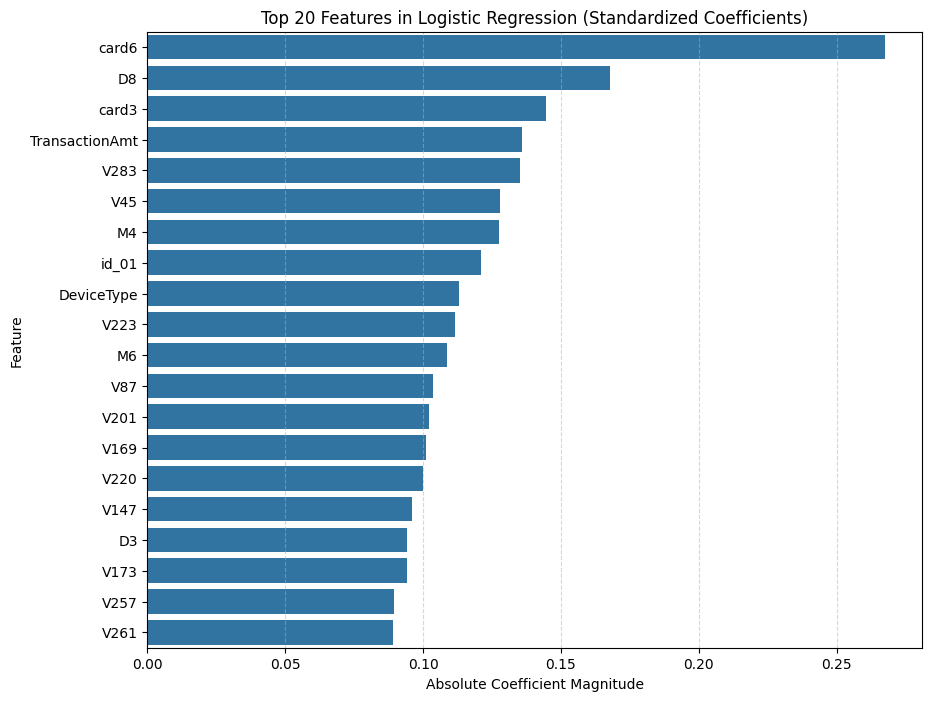

✅ Graph saved as Logistic_Regression_Top20_Features.png


In [2]:
# =========================================================
# 6. THESIS VALIDATION: LOGISTIC REGRESSION FEATURE RANKING
# Metric: Absolute Coefficient Magnitude (Standardized)
# =========================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- 📊 LOGISTIC REGRESSION FEATURE RANKINGS 📊 ---")

# 1. Extract Coefficients
# Logistic Regression learns a specific weight (coefficient) for every feature.
# These weights represent the log-odds change in the target variable for a 1-unit change in the feature.
#
# Since the data was scaled using StandardScaler, the magnitude directly correlates to importance.
# np.abs() is used because a large negative number (strong protection against fraud) is just as important
# as a large positive number (strong indicator of fraud).
coeffs = np.abs(lr_model.coef_[0])

# Create DataFrame
# Maps the feature names to their corresponding learned weights.
imp_df = pd.DataFrame({
    'Feature': features,  # The list of feature names used in training
    'Importance': coeffs, # The absolute value of the coefficients
    # Retains the original sign (+/-) to understand the relationship direction.
    # Positive (+) = Increases Fraud Risk. Negative (-) = Decreases Fraud Risk.
    'Direction': ['Positive' if c > 0 else 'Negative' for c in lr_model.coef_[0]]
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Add Rank
# Assigns a numerical rank (1 = Most Important) based on the sorted importance values.
imp_df['Rank'] = imp_df.index + 1

# 2. Check Engineered Features
# Defines the specific list of custom-engineered features to validate the thesis.
my_features = [
    'User_Trans_Count',         # Velocity
    'Amt_Deviation',            # Contextual Spending
    'Time_Behavior_Deviation',  # Contextual Timing
    'hour'                      # Temporal
]

# Sets up a formatted table header for clear output.
print(f"{'Feature Name':<25} | {'Rank':<6} | {'Coeff (Abs)':<12} | {'Direction':<10} | {'Status'}")
print("-" * 80)

found_features = []
# Iterates through the list of engineered features to find their specific ranking.
for feat in my_features:
    # Checks if the feature exists in the model's feature list.
    if feat in imp_df['Feature'].values:
        # Extracts the specific row for this feature.
        row = imp_df[imp_df['Feature'] == feat].iloc[0]
        rank = int(row['Rank'])

        # Thesis Interpretation Status (Adjusted for ~430 features):
        if rank <= 50: status = "🌟 STAR (Top 50)"
        elif rank <= 150: status = "✅ STRONG (Top 150)"
        elif rank <= 250: status = "🔹 SUPPORTIVE (Top 250)"
        else: status = "🔸 WEAK (Shadowed)"

        # Prints the rank, coefficient magnitude, direction, and status.
        print(f"{feat:<25} | #{rank:<5} | {row['Importance']:<12.4f} | {row['Direction']:<10} | {status}")
        # Adds to a list for color-coding the graph later.
        found_features.append(feat)
    else:
        # Handles cases where the feature was excluded (e.g., intermediate features).
        print(f"{feat:<25} | ------ | 0.0000       | ---------- | ❌ NOT USED")

# 3. Compare with Top 1 Feature
# Identifies the single most influential feature in the entire dataset.
top_feat = imp_df.iloc[0]
print("\n--- 🏆 COMPARISON WITH #1 FEATURE ---")
print(f"Top Feature is: {top_feat['Feature']} (Coeff: {top_feat['Importance']:.4f}, Direction: {top_feat['Direction']})")

# 4. Visualization (Top 20 Coefficients)
# Checks if any custom features were found to avoid plotting errors.
if len(found_features) > 0:
    plt.figure(figsize=(10, 8))
    # Selects only the top 20 most important features for the plot.
    plot_df = imp_df.head(20)

    # Defines color logic:
    # Red = Custom Engineered Features (Thesis Validation).
    # Blue = Standard/Raw Features.
    colors = ['red' if x in my_features else '#1f77b4' for x in plot_df['Feature']]

    # Generates a horizontal bar chart.
    sns.barplot(x='Importance', y='Feature', data=plot_df, palette=colors)
    plt.title('Top 20 Features in Logistic Regression (Standardized Coefficients)')
    plt.xlabel('Absolute Coefficient Magnitude')
    # Adds a grid for easier reading of values.
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    # Saves the figure as a high-resolution PNG file.
    plt.savefig('Logistic_Regression_Top20_Features.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("✅ Graph saved as Logistic_Regression_Top20_Features.png")